In [1]:
#Paths
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

# Drive paths (source of truth)
DRIVE_TRAIN='/content/drive/MyDrive/AIML/FinalCoursework/data/asl_alphabet_train/asl_alphabet_train'
DRIVE_TEST='/content/drive/MyDrive/AIML/FinalCoursework/data/asl-alphabet-test'
MODELS_DIR='/content/drive/MyDrive/AIML_FINAL_COURSEWORK/SavedModels'

os.makedirs(MODELS_DIR, exist_ok=True)

print("Drive train exists:",os.path.exists(DRIVE_TRAIN))
print("Drive test exists :",os.path.exists(DRIVE_TEST))
print("Models dir :", MODELS_DIR)

Drive train exists: True
Drive test exists : True
Models dir : /content/drive/MyDrive/AIML_FINAL_COURSEWORK/SavedModels


In [2]:
# Copy data to local SSD for ~5x faster I/O during training
LOCAL_TRAIN='/content/asl_train'
LOCAL_TEST='/content/asl_test'

if not os.path.exists(LOCAL_TRAIN):
    print("Copying training set from Drive to local SSD...")
    shutil.copytree(DRIVE_TRAIN, LOCAL_TRAIN)
    print("Training set copied.")
else:
    print("Training set already in local storage.")

if not os.path.exists(LOCAL_TEST):
    print("Copying test set from Drive to local SSD.")
    shutil.copytree(DRIVE_TEST, LOCAL_TEST)
    print("Test set copied.")
else:
    print("Test set already in local storage.")

TRAIN_DIR = LOCAL_TRAIN
TEST_DIR  = LOCAL_TEST

print(f"\nTrain :{TRAIN_DIR}")
print(f"Test :{TEST_DIR}")
print(f"Models:{MODELS_DIR}")

Copying training set from Drive to local SSD...
Training set copied.
Copying test set from Drive to local SSD.
Test set copied.

Train :/content/asl_train
Test :/content/asl_test
Models:/content/drive/MyDrive/AIML_FINAL_COURSEWORK/SavedModels


## Imports, Hyperparameters, and Data Generators

Setting up everything that gets used by all three models. The augmentation choices (rotation, zoom, shifts, brightness, horizontal flip is however not applied) are deliberate: flipping an ASL sign would change its meaning.

In [3]:
#importing
import time
import json
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,ReduceLROnPlateau, Callback)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import pandas as pd

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Hyperparameters (Section 2.5.1)
IMG_SIZE    = (96, 96)   # Resized from 200x200 for training efficiency
IMG_HEIGHT  = 96
IMG_WIDTH   = 96
CHANNELS    = 3
BATCH_SIZE  = 32
EPOCHS      = 25
NUM_CLASSES = 27

print(f"Parameters")
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Classes: {NUM_CLASSES}")

Parameters
Image size: (96, 96)
Batch size: 32
Epochs: 25
Classes: 27


## Data Augmentation and Dataset Generator Setup
This section prepares the dataset using Keras ImageDataGenerator.


*   The images are rescaled to normalize pixel values between 0 and 1 and resized to a fixed input size.
*    Data augmentation techniques such as rotation, zoom, shifting, and brightness adjustment are applied to the training set to improve generalization and reduce overfitting.

*   Horizontal flipping is disabled as it may alter the semantic meaning of ASL hand signs.

*   The dataset is split into 80% training and 20% validation using the validation_split parameter.
*   Separate generators are created for training, validation, and testing, ensuring efficient batch-wise data loading during model training.



  

In [6]:
# Data generators (80% train / 20% val split via validation_split)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    horizontal_flip=False,           # ASL signs are not flip-invariant
    validation_split=0.2
)

val_datagen  = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42
)
val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

class_names = list(train_generator.class_indices.keys())

print(f"\nData loaded:")
print(f"Training samples: {train_generator.samples:,}")
print(f"Validation samples: {val_generator.samples:,}")
print(f"Test samples: {test_generator.samples:,}")
print(f"Split: 80% train / 20% validation")
print(f"Preprocessing: Resized to 96x96, normalized to [0,1]")
print(f"Augmentation: Rotation, Zoom, Shift, Brightness")

Found 64800 images belonging to 27 classes.
Found 16200 images belonging to 27 classes.
Found 810 images belonging to 27 classes.

Data loaded:
Training samples: 64,800
Validation samples: 16,200
Test samples: 810
Split: 80% train / 20% validation
Preprocessing: Resized to 96x96, normalized to [0,1]
Augmentation: Rotation, Zoom, Shift, Brightness


## Visualizing the Augmented Samples

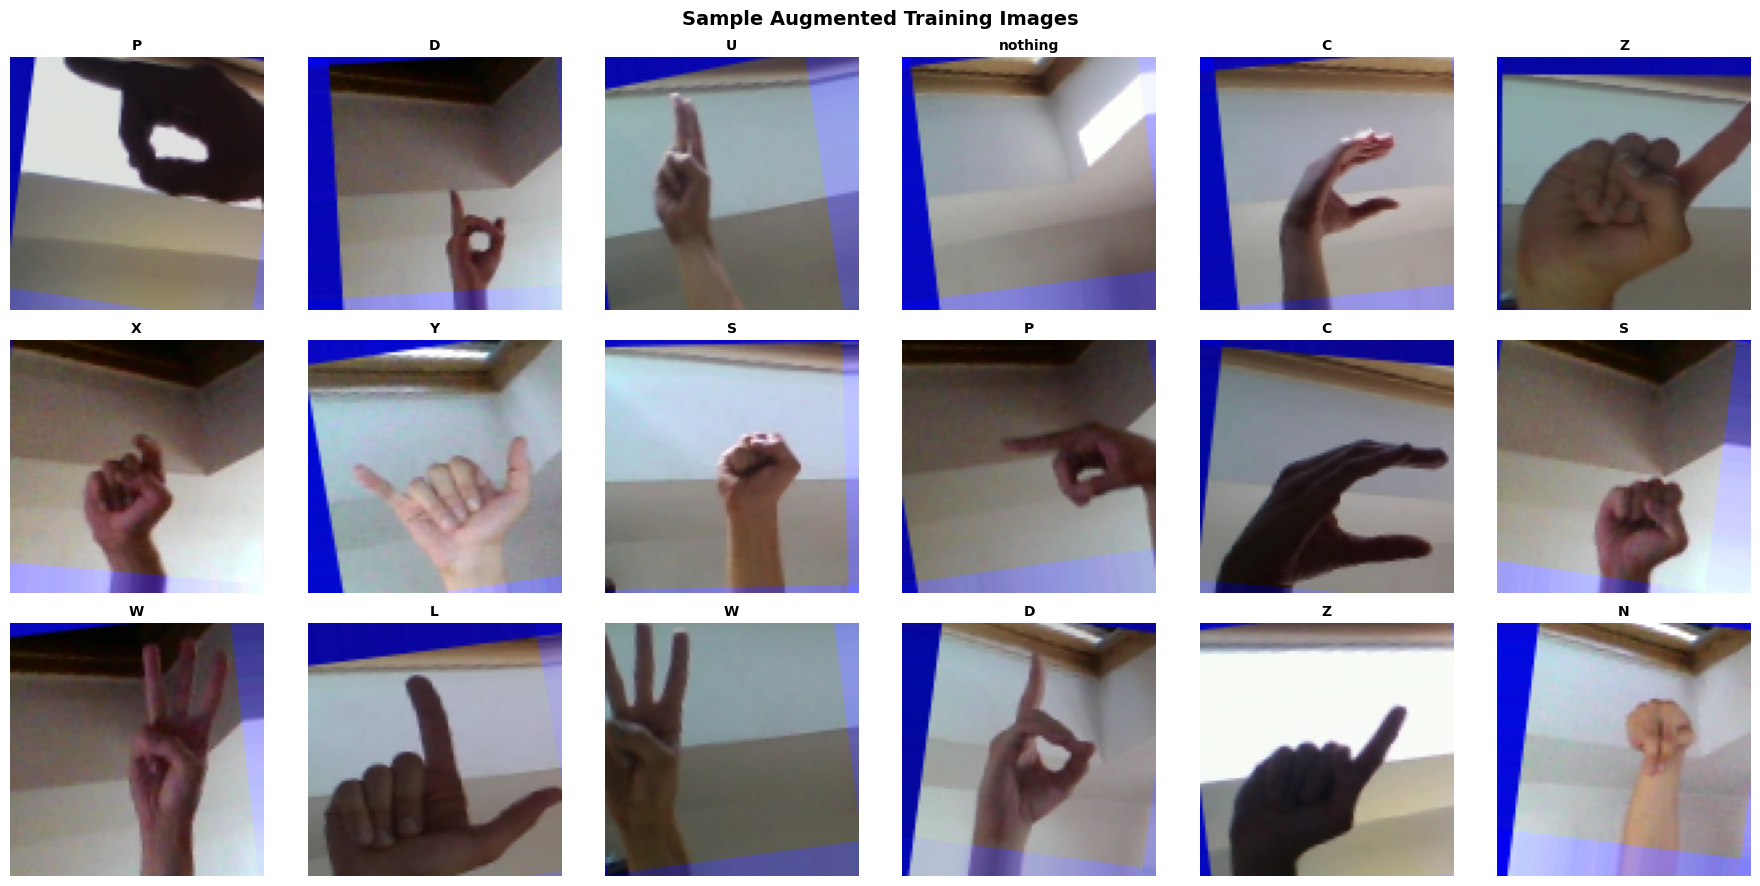

In [ ]:
# Visualize augmented samples (Section 2.5.1)
sample_imgs, sample_labels = next(train_generator)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Sample Augmented Training Images',
             fontsize=14, fontweight='bold')
for i in range(18):
    ax = axes[i // 6][i % 6]
    ax.imshow(sample_imgs[i])
    ax.set_title(class_names[np.argmax(sample_labels[i])],fontsize=10, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Resilient training utilities to support checkpointing, logging and resuming.
To make training safer and restartable after runtime disconnection.

This is the core of the resilience design. After every epoch:
1. **`*_best.keras`** — Keras' `ModelCheckpoint` writes the best-val-accuracy model so far.
2. **`*_last.keras`** — Our custom `EpochSaver` writes the *most recent* model.
3. **`*_history.json`** — Cumulative history is rewritten with the latest epoch appended.
4. **`*_epoch.json`** — The completed epoch index is recorded.

If the runtime dies, run the **Resume Training** cell that follows each main training cell. It loads `*_last.keras` and `*_history.json`, then calls `model.fit` with `initial_epoch` set to the last completed epoch.



*   Best Model(*_best.keras): Saves the model with the best validation performance so far
*   Latest Model(*_last.keras): Saves the most recent version of the model after every epoch
*   Training History(*_history.json): Stores accuracy and loss values for all completed epoch in a json file
*   Last Epoch(*_epoch.json): Keeps track of the last completed epoch number.



In [5]:
class EpochSaver(Callback):
    """After every epoch: save full model, append history, record epoch index."""
    def __init__(self, tag, models_dir):
        super().__init__()
        self.tag        = tag
        self.last_path  = f'{models_dir}/{tag}_last.keras'
        self.hist_path  = f'{models_dir}/{tag}_history.json'
        self.epoch_path = f'{models_dir}/{tag}_epoch.json'

        # Load any existing history (resume case)
        if os.path.exists(self.hist_path):
            with open(self.hist_path) as f:
                self.history = json.load(f)
        else:
            self.history = {}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        for k, v in logs.items():
            self.history.setdefault(k, []).append(float(v))

        self.model.save(self.last_path)

        with open(self.hist_path, 'w') as f:
            json.dump(self.history, f)

        with open(self.epoch_path, 'w') as f:
            json.dump({'last_completed_epoch': int(epoch)}, f)

        print(f"  [EpochSaver] Saved {self.tag}_last.keras + history "
              f"(through epoch {epoch + 1})")


def get_resume_state(tag, models_dir):
    """Return (last_completed_epoch, history_dict) or (None, None)."""
    epoch_path = f'{models_dir}/{tag}_epoch.json'
    hist_path  = f'{models_dir}/{tag}_history.json'
    if not (os.path.exists(epoch_path) and os.path.exists(hist_path)):
        return None, None
    with open(epoch_path) as f:
        last_epoch = json.load(f)['last_completed_epoch']
    with open(hist_path) as f:
        hist = json.load(f)
    return last_epoch, hist


def make_callbacks(tag, monitor='val_accuracy', mode='max',
                   es_patience=7, lr_patience=3, min_lr=1e-6):
    """Standard callback bundle used by every training cell."""
    return [
        EarlyStopping(monitor='val_loss', patience=es_patience,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=f'{MODELS_DIR}/{tag}_best.keras',
                        monitor=monitor, mode=mode,
                        save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=lr_patience, min_lr=min_lr, verbose=1),
        EpochSaver(tag=tag, models_dir=MODELS_DIR),
    ]

print("Resilient training utilities ready.")

Resilient training utilities ready.


## Step 4 — Baseline CNN from Scratch (Section 2.5.2)

**Architecture (per the brief):**
- 3 Convolutional layers (32 → 64 → 128 filters, 3×3 kernels, ReLU), each followed by MaxPooling
- 3 Fully-Connected layers (256 → 128 → 64, ReLU)
- Output layer: 27-way softmax

**Training:** Adam optimizer, categorical crossentropy, with the resilient callback bundle.

In [ ]:
def build_baseline_model():
    """3 Conv+Pool blocks, 3 FC layers, softmax output. Section 2.5.2 spec."""
    return models.Sequential([
        # Conv Block 1 — 32 filters
        layers.Conv2D(32, (3, 3), activation='relu',
                      input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 2 — 64 filters
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 3 — 128 filters
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='Baseline_CNN')


# Load existing _last checkpoint if present, else build fresh
baseline_last_path = f'{MODELS_DIR}/baseline_last.keras'
if os.path.exists(baseline_last_path):
    print("Found existing baseline checkpoint — loading.")
    baseline_model = load_model(baseline_last_path)
else:
    print("No checkpoint found — building fresh baseline.")
    baseline_model = build_baseline_model()
    baseline_model.compile(optimizer='adam',
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])

baseline_model.summary()

No checkpoint found — building fresh baseline.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │         1,755 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,855,003 (18.52 MB)

 Trainable params: 4,855,003 (18.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Baseline training, resumes automatically if a checkpoint exists
last_epoch, _ = get_resume_state('baseline', MODELS_DIR)
initial_epoch = (last_epoch + 1) if last_epoch is not None else 0

if initial_epoch >= EPOCHS:
    print(f"Baseline already trained for {initial_epoch} epochs. Skipping.")
    baseline_time = 0.0
else:
    print(f"Training Baseline CNN  (starting at epoch {initial_epoch + 1}/{EPOCHS})")
    train_generator.reset()
    val_generator.reset()

    start = time.time()
    baseline_history = baseline_model.fit(
        train_generator,
        epochs=EPOCHS,
        initial_epoch=initial_epoch,
        validation_data=val_generator,
        callbacks=make_callbacks('baseline', es_patience=10),
        verbose=1
    )
    baseline_time = time.time() - start
    print(f"\nBaseline training complete: {baseline_time/60:.2f} mins")

    # Persist training time for the comparison table
    with open(f'{MODELS_DIR}/baseline_time.json', 'w') as f:
        json.dump({'training_time_seconds': baseline_time}, f)

Training Baseline CNN  (starting at epoch 1/25)
Epoch 1/25
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.4566 - loss: 1.7688
Epoch 1: val_accuracy improved from None to 0.74531, saving model to /content/drive/MyDrive/AIML_FINAL_COURSEWORK/SavedModels/baseline_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AIML_FINAL_COURSEWORK/SavedModels/baseline_best.keras
  [EpochSaver] Saved baseline_last.keras + history (through epoch 1)
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 279s 138ms/step - accuracy: 0.6786 - loss: 0.9990 - val_accuracy: 0.7453 - val_loss: 0.8538 - learning_rate: 0.0010
Epoch 2/25
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.8992 - loss: 0.2852
Epoch 2: val_accuracy improved from 0.74531 to 0.79204, saving model to /content/drive/MyDrive/AIML_FINAL_COURSEWORK/SavedModels/baseline_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/AIML_FINAL_COURSEWORK/SavedModels/baseline_best.keras
  [EpochSaver] Saved baseline_last.ke

In [ ]:
# Load best-checkpoint version for evaluation
baseline_model = load_model(f'{MODELS_DIR}/baseline_best.keras')
print("Baseline best checkpoint loaded.")

with open(f'{MODELS_DIR}/baseline_history.json') as f:
    baseline_history_dict = json.load(f)

if os.path.exists(f'{MODELS_DIR}/baseline_time.json'):
    with open(f'{MODELS_DIR}/baseline_time.json') as f:
        baseline_time = json.load(f)['training_time_seconds']
else:
    baseline_time = 0.0
    print("Warning: baseline_time.json not found. Time set to 0.")

print(f"Total epochs trained: {len(baseline_history_dict['accuracy'])}")
print(f"Best val_accuracy: {max(baseline_history_dict['val_accuracy'])*100:.2f}%")

Baseline best checkpoint loaded.
Total epochs trained: 17
Best val_accuracy: 86.85%


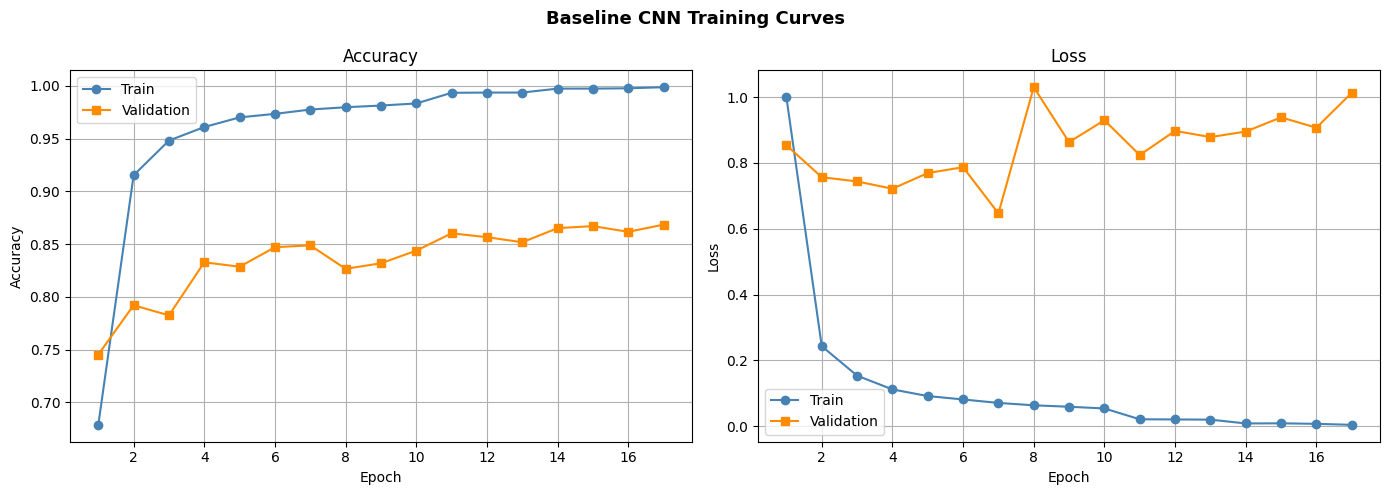

In [ ]:
# Training curves for Baseline CNN
b_epochs = range(1, len(baseline_history_dict['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Baseline CNN Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(b_epochs, baseline_history_dict['accuracy'],'o-', label='Train', color='steelblue')
axes[0].plot(b_epochs, baseline_history_dict['val_accuracy'],'s-',label='Validation', color='darkorange')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(b_epochs, baseline_history_dict['loss'],'o-',label='Train',color='steelblue')
axes[1].plot(b_epochs, baseline_history_dict['val_loss'],'s-',label='Validation',color='darkorange')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/baseline_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Baseline evaluation — accuracy, precision, recall, F1, confusion matrix
val_generator.reset()
val_loss, val_acc = baseline_model.evaluate(val_generator, verbose=1)
print(f"\nBaseline CNN Results:")
print(f"  Validation Accuracy : {val_acc*100:.2f}%")
print(f"  Validation Loss     : {val_loss:.4f}")

val_generator.reset()
b_preds = np.argmax(baseline_model.predict(val_generator, verbose=1), axis=1)
b_true  = val_generator.classes

print("\nClassification Report:")
print(classification_report(b_true, b_preds, target_names=class_names))

507/507 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.8685 - loss: 1.0131

Baseline CNN Results:
  Validation Accuracy : 86.85%
  Validation Loss     : 1.0131
507/507 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step

Classification Report:
              precision    recall  f1-score   support

           A       0.99      0.86      0.92       600
           B       0.92      0.99      0.95       600
           C       1.00      1.00      1.00       600
           D       1.00      0.93      0.97       600
           E       0.76      1.00      0.86       600
           F       0.99      1.00      1.00       600
           G       0.89      0.95      0.92       600
           H       0.96      0.88      0.92       600
           I       1.00      0.79      0.88       600
           J       0.97      0.97      0.97       600
           K       0.99      0.98      0.99       600
           L       1.00      0.99      1.00       600
           M       0.64      0.77      0.70       600
           N  

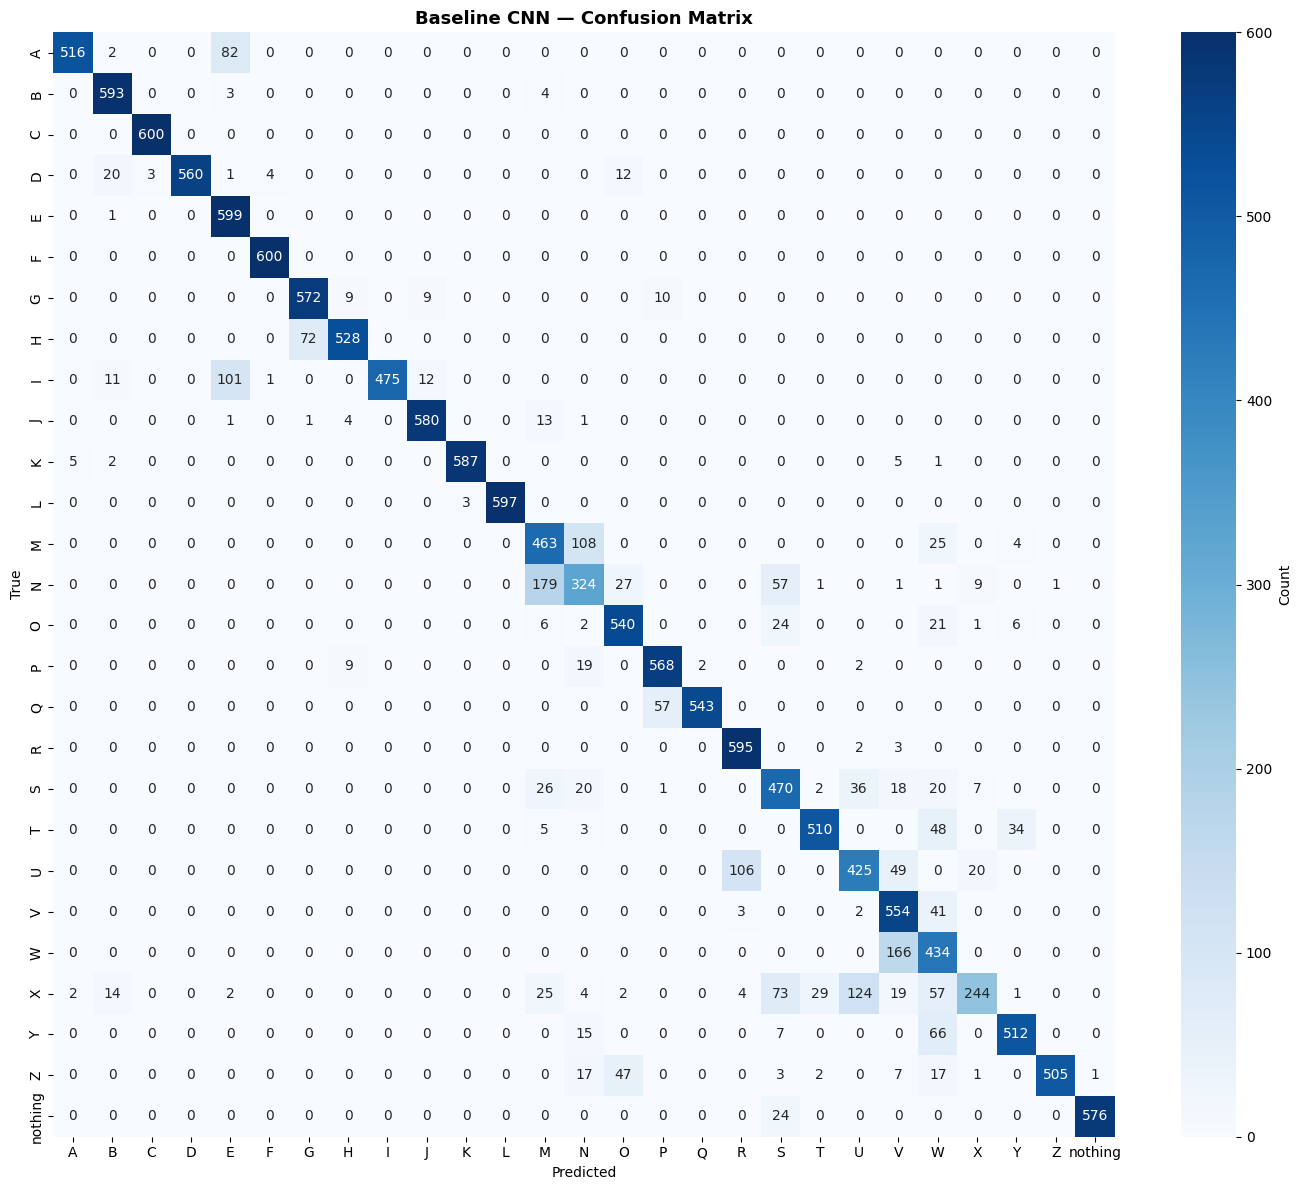

In [ ]:
# Confusion matrix — Baseline
cm_b = confusion_matrix(b_true, b_preds)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            cbar_kws={'label': 'Count'})
ax.set_title('Baseline CNN — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

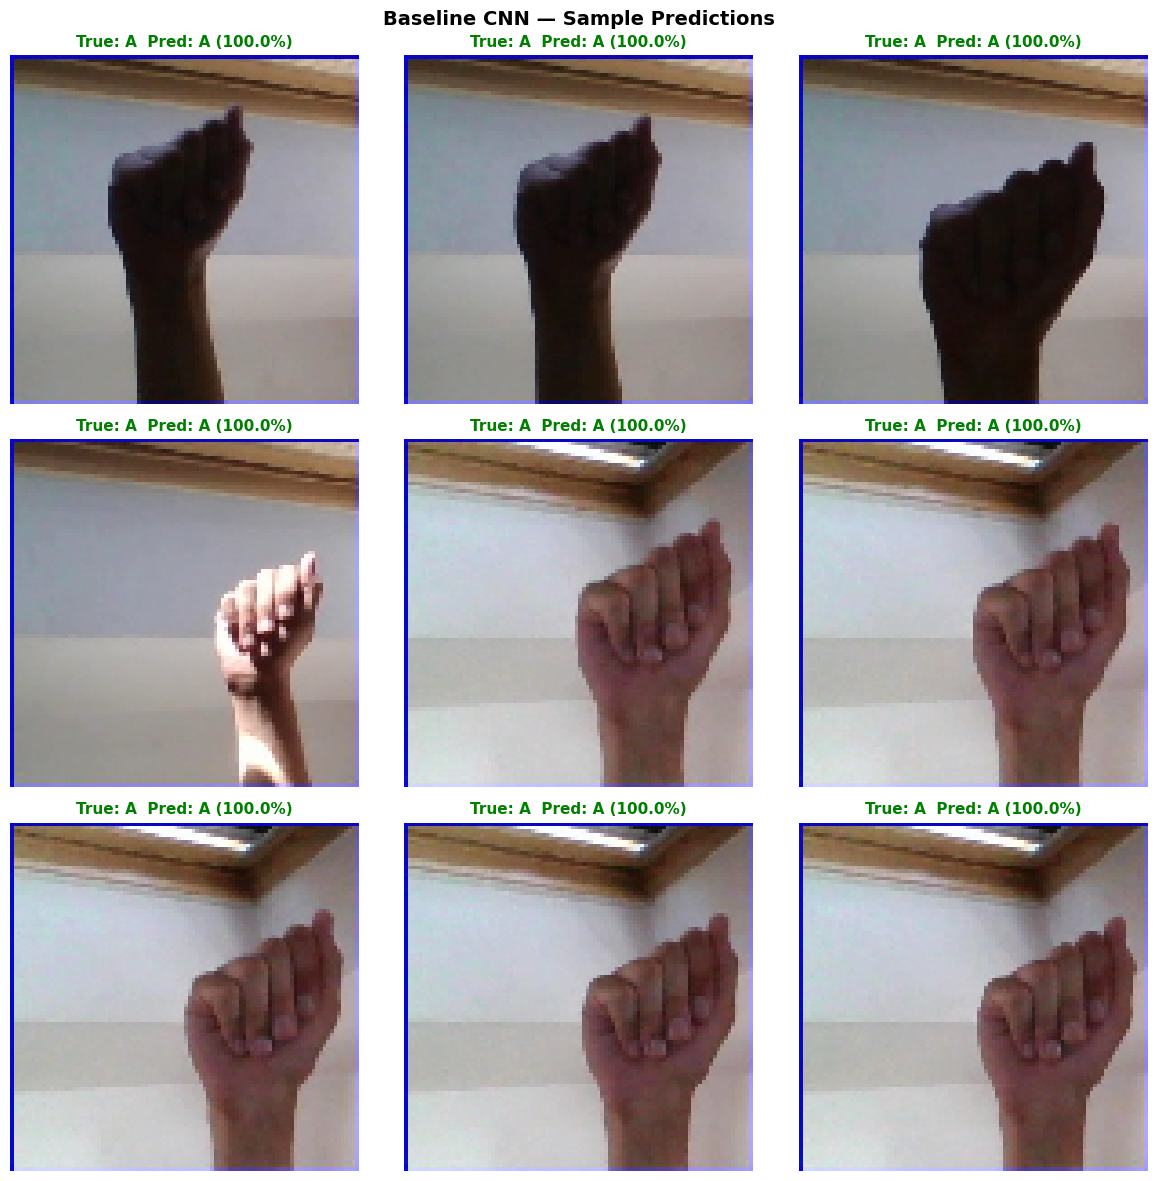

In [ ]:
# Sample inference (Section 2.5.2)
val_generator.reset()
sample_imgs, sample_labels = next(val_generator)
preds = baseline_model.predict(sample_imgs, verbose=0)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Baseline CNN — Sample Predictions', fontsize=14, fontweight='bold')
for i in range(9):
    ax    = axes[i // 3][i % 3]
    true  = class_names[np.argmax(sample_labels[i])]
    pred  = class_names[np.argmax(preds[i])]
    conf  = preds[i][np.argmax(preds[i])] * 100
    color = 'green' if true == pred else 'red'
    ax.imshow(sample_imgs[i])
    ax.set_title(f'True: {true}  Pred: {pred} ({conf:.1f}%)',
                 fontsize=11, color=color, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/baseline_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Store results dict
results = {}
results['Baseline CNN'] = {
    'val_accuracy'  : float(val_acc),
    'val_loss'      : float(val_loss),
    'training_time' : float(baseline_time),
}
print("Baseline results stored.")

Baseline results stored.


## Step 5 — Improved Deep CNN with Regularization (Section 2.5.3)

**What changed from the Baseline:**

| Change | Reason |
|---|---|
| 3 → 6 convolutional layers | Brief requires "at least double" the layer count of the baseline |
| Filters: 32→64→128 → 32→64→128→256 with two doubled-conv blocks | More representational capacity |
| BatchNormalization after every Conv | Stabilizes training, allows higher learning rates |
| Dropout(0.5) after Flatten + Dropout(0.4) between Dense layers | Stops co-adaptation; the main overfitting fix |
| L2 weight regularization (1e-4) on Dense layers | Penalizes large weights; encourages generalization |
| `ReduceLROnPlateau` callback | Halves LR when val_loss stalls — finer convergence |

In [7]:
def build_improved_model():
    """6 conv layers (>=2x baseline), BatchNorm, Dropout, L2 — Section 2.5.3 spec."""
    return models.Sequential([
        # Conv Block 1 — 32 filters (2 conv layers)
        layers.Conv2D(32, (3, 3), activation='relu',
                      input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 2 — 64 filters (2 conv layers)
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 3 — 128 filters
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        # Conv Block 4 — 256 filters
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dropout(0.5),

        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.4),

        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.4),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='Improved_CNN')


improved_last_path = f'{MODELS_DIR}/improved_last.keras'
if os.path.exists(improved_last_path):
    print("Found existing improved checkpoint, loading.")
    improved_model = load_model(improved_last_path)
else:
    print("No checkpoint found — building fresh improved model.")
    improved_model = build_improved_model()
    improved_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy'])

improved_model.summary()

Found existing improved checkpoint — loading.


Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             

 Total params: 15,880,499 (60.58 MB)

 Trainable params: 5,293,115 (20.19 MB)

 Non-trainable params: 1,152 (4.50 KB)

 Optimizer params: 10,586,232 (40.38 MB)

In [8]:
# Train Improved CNN resumes automatically if a checkpoint exists
last_epoch, _ = get_resume_state('improved', MODELS_DIR)
initial_epoch = (last_epoch + 1) if last_epoch is not None else 0

if initial_epoch >= EPOCHS:
    print(f"Improved CNN already trained for {initial_epoch} epochs. Skipping.")
    improved_time = 0.0
else:
    print(f"Training Improved CNN  (starting at epoch {initial_epoch + 1}/{EPOCHS})")
    train_generator.reset()
    val_generator.reset()

    start = time.time()
    improved_history = improved_model.fit(
        train_generator,
        epochs=EPOCHS,
        initial_epoch=initial_epoch,
        validation_data=val_generator,
        callbacks=make_callbacks('improved', es_patience=7),
        verbose=1
    )
    improved_time_this_run = time.time() - start

    # Accumulate across resumes
    if os.path.exists(f'{MODELS_DIR}/improved_time.json'):
        with open(f'{MODELS_DIR}/improved_time.json') as f:
            improved_time = json.load(f)['training_time_seconds'] + improved_time_this_run
    else:
        improved_time = improved_time_this_run

    with open(f'{MODELS_DIR}/improved_time.json', 'w') as f:
        json.dump({'training_time_seconds': improved_time}, f)

    print(f"\nImproved CNN training complete (this run): {improved_time_this_run/60:.2f} mins")
    print(f"Cumulative training time across all resumes : {improved_time/60:.2f} mins")

Training Improved CNN  (starting at epoch 11/25)
Epoch 11/25
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9802 - loss: 0.1959
Epoch 11: val_accuracy improved from None to 0.87660, saving model to /content/drive/MyDrive/AIML_FINAL_COURSEWORK/SavedModels/improved_best.keras

Epoch 11: finished saving model to /content/drive/MyDrive/AIML_FINAL_COURSEWORK/SavedModels/improved_best.keras
  [EpochSaver] Saved improved_last.keras + history (through epoch 11)
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 339s 160ms/step - accuracy: 0.9811 - loss: 0.1924 - val_accuracy: 0.8766 - val_loss: 0.5873 - learning_rate: 1.0000e-04
Epoch 12/25
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9835 - loss: 0.1837
Epoch 12: val_accuracy did not improve from 0.87660
  [EpochSaver] Saved improved_last.keras + history (through epoch 12)
2025/2025 ━━━━━━━━━━━━━━━━━━━━ 319s 158ms/step - accuracy: 0.9835 - loss: 0.1827 - val_accuracy: 0.8529 - val_loss: 0.8744 - learning_rate: 1.0000e-04
Epoch 13/25
202

In [9]:
# Load best-checkpoint version for evaluation
improved_model = load_model(f'{MODELS_DIR}/improved_best.keras')
print("Improved CNN best checkpoint loaded.")

with open(f'{MODELS_DIR}/improved_history.json') as f:
    improved_history_dict = json.load(f)

if os.path.exists(f'{MODELS_DIR}/improved_time.json'):
    with open(f'{MODELS_DIR}/improved_time.json') as f:
        improved_time = json.load(f)['training_time_seconds']
else:
    improved_time = 0.0

print(f"Total epochs trained: {len(improved_history_dict['accuracy'])}")
print(f"Best val_accuracy   : {max(improved_history_dict['val_accuracy'])*100:.2f}%")

Improved CNN best checkpoint loaded.
Total epochs trained: 25
Best val_accuracy   : 92.84%


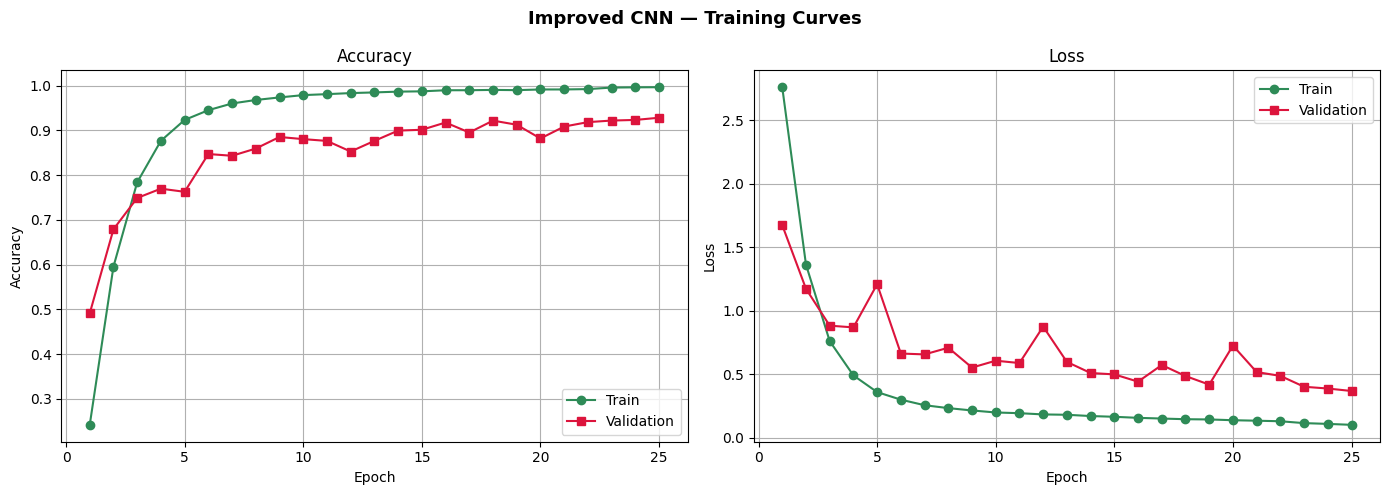

In [10]:
# Improved CNN — training curves
i_epochs = range(1, len(improved_history_dict['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Improved CNN — Training Curves', fontsize=13, fontweight='bold')

axes[0].plot(i_epochs, improved_history_dict['accuracy'],     'o-', label='Train',      color='seagreen')
axes[0].plot(i_epochs, improved_history_dict['val_accuracy'], 's-', label='Validation', color='crimson')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(i_epochs, improved_history_dict['loss'],     'o-', label='Train',      color='seagreen')
axes[1].plot(i_epochs, improved_history_dict['val_loss'], 's-', label='Validation', color='crimson')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/improved_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Improved CNN — evaluation
val_generator.reset()
imp_val_loss, imp_val_acc = improved_model.evaluate(val_generator, verbose=1)
print(f"\nImproved CNN Results:")
print(f"  Validation Accuracy : {imp_val_acc*100:.2f}%")
print(f"  Validation Loss     : {imp_val_loss:.4f}")

val_generator.reset()
imp_preds = np.argmax(improved_model.predict(val_generator, verbose=1), axis=1)

print("\nClassification Report:")
print(classification_report(val_generator.classes, imp_preds, target_names=class_names))

507/507 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.9284 - loss: 0.3673

Improved CNN Results:
  Validation Accuracy : 92.84%
  Validation Loss     : 0.3673
507/507 ━━━━━━━━━━━━━━━━━━━━ 18s 34ms/step

Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       600
           B       1.00      1.00      1.00       600
           C       0.99      1.00      1.00       600
           D       1.00      0.99      1.00       600
           E       0.84      0.99      0.91       600
           F       0.98      0.99      0.99       600
           G       0.99      0.97      0.98       600
           H       0.97      1.00      0.99       600
           I       1.00      0.75      0.86       600
           J       0.95      0.94      0.95       600
           K       1.00      1.00      1.00       600
           L       1.00      1.00      1.00       600
           M       0.70      1.00      0.82       600
           N  

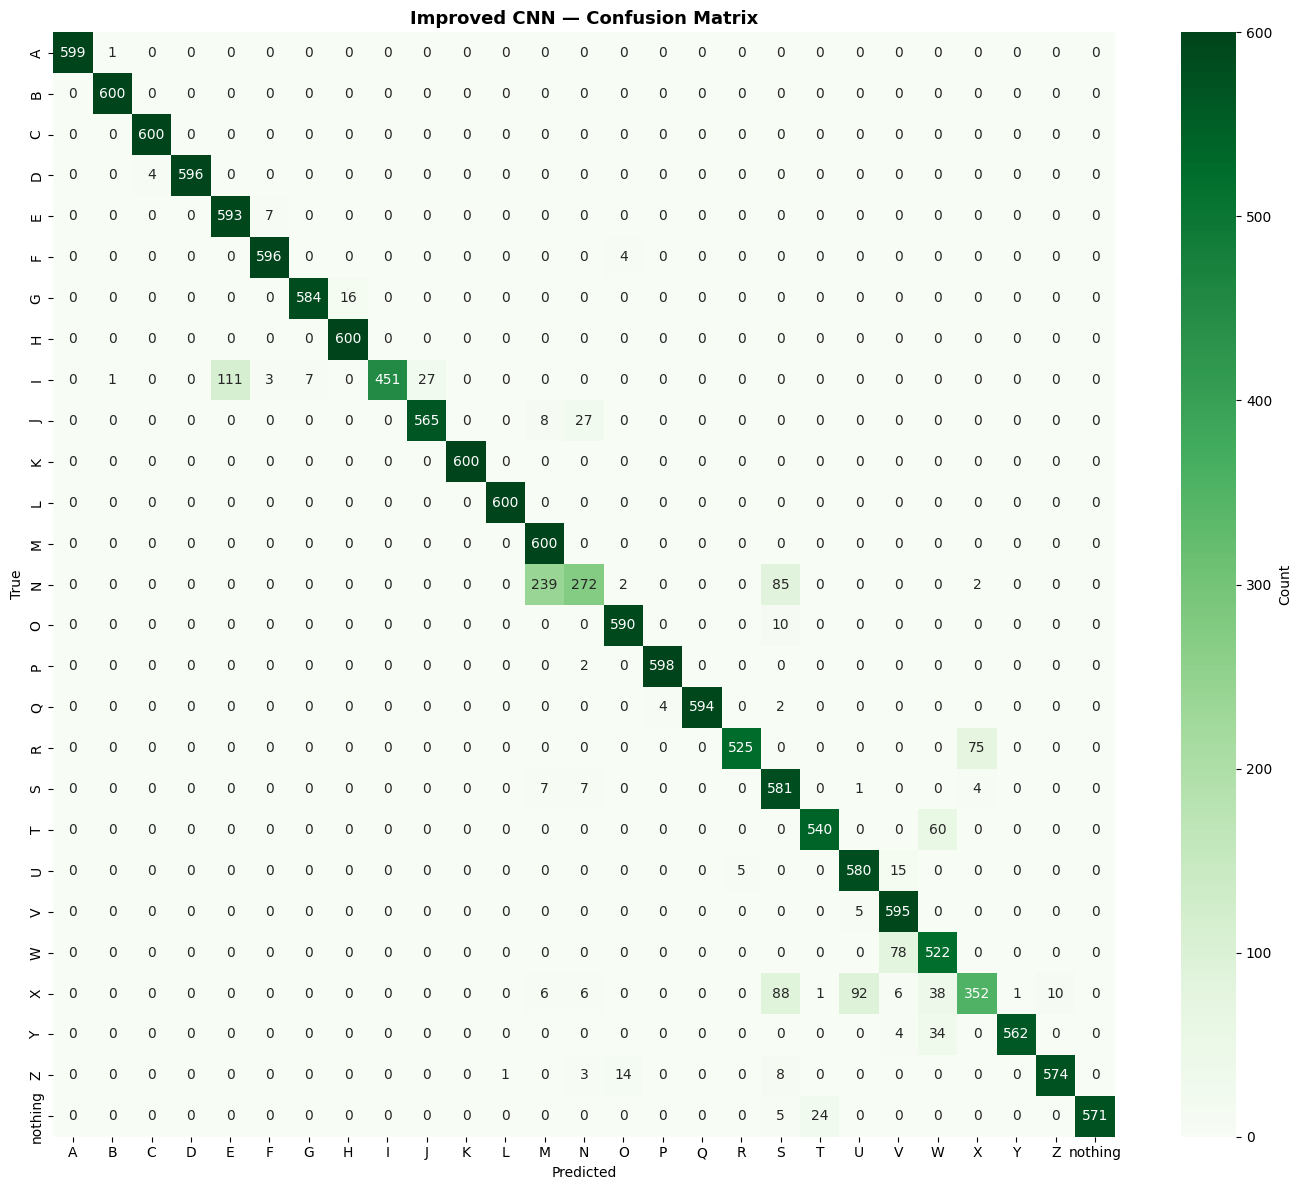

In [12]:
# Confusion matrix — Improved CNN
cm_imp = confusion_matrix(val_generator.classes, imp_preds)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            cbar_kws={'label': 'Count'})
ax.set_title('Improved CNN — Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/improved_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

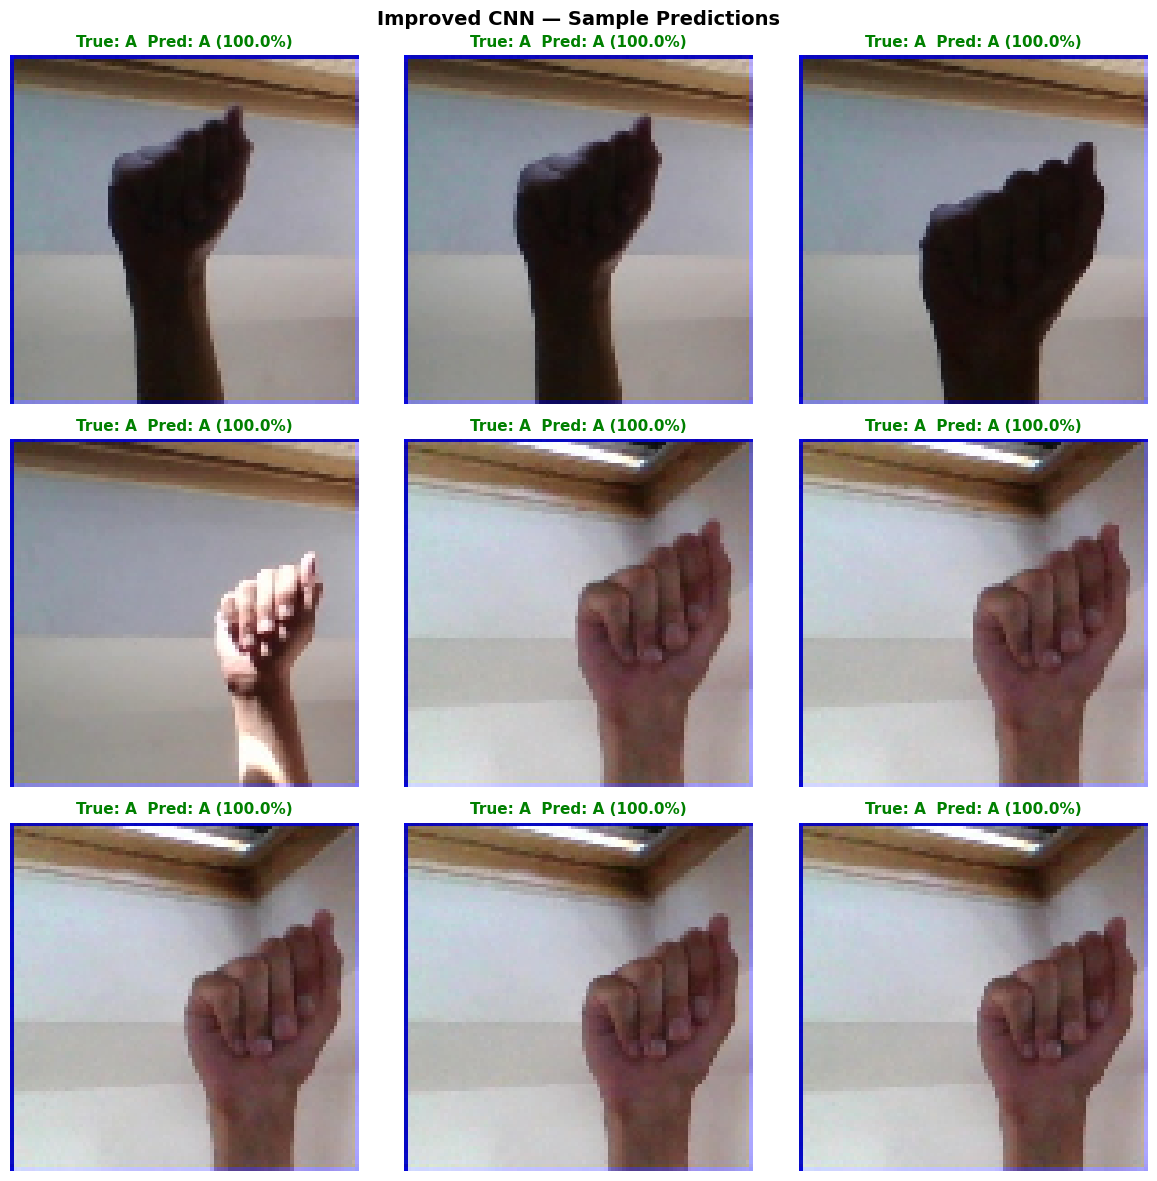

In [13]:
# Sample inference — Improved CNN
val_generator.reset()
sample_imgs, sample_labels = next(val_generator)
preds = improved_model.predict(sample_imgs, verbose=0)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Improved CNN — Sample Predictions', fontsize=14, fontweight='bold')
for i in range(9):
    ax    = axes[i // 3][i % 3]
    true  = class_names[np.argmax(sample_labels[i])]
    pred  = class_names[np.argmax(preds[i])]
    conf  = preds[i][np.argmax(preds[i])] * 100
    color = 'green' if true == pred else 'red'
    ax.imshow(sample_imgs[i])
    ax.set_title(f'True: {true}  Pred: {pred} ({conf:.1f}%)',
                 fontsize=11, color=color, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/improved_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Store Improved results
results = {} # Initialize results if not already defined (e.g., after kernel restart)
results['Improved CNN'] = {
    'val_accuracy'  : float(imp_val_acc),
    'val_loss'      : float(imp_val_loss),
    'training_time' : float(improved_time),
}
print("Improved CNN results stored.")

NameError: name 'results' is not defined